In [ ]:
!pip install -U storywrangler

In [5]:
# latest py-allotax version still on a branch
# !pip install git+https://github.com/compstorylab/py-allotax.git@allotax-core

In [3]:
# colab's slim Ubuntu image lacks Chrome's system libraries for writing the allotax plot
# !apt-get -qq update && apt-get -qq install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libasound2 libgbm1 libnss3 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2

In [2]:
# local packages
from storywrangler import Storywrangler
from py_allotax import allotaxonograph

import pandas as pd
# import matplotlib.pyplot as plt

# plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
import storywrangler
print(storywrangler.__version__)

0.0.10


In [4]:
client=Storywrangler()

## Exploring datasets

In [5]:
registry = client.registry

In [6]:
client.registry.list().df().head()

,catalog,domain,dataset_id,version,data_location,data_format,description,endpoint_schema,level_order,filter_values,created_at,updated_at
0,vcsi,babynames,ngrams,latest,[/users/j/s/jstonge1/babynames/metadata.duckla...,parquet,"Baby names by popularity, year, and location w...","{'type': 'types-counts', 'type_column': None, ...",None,"{'sex': ['F', 'M']}",2026-04-07T16:35:14.417279+00:00,2026-07-17T15:03:23.490632+00:00
1,vcsi,open-academic-analytics,academic-research-groups,latest,/users/j/s/jstonge1/academic-research-groups/a...,parquet,"UVM faculty roster with OpenAlex IDs, departme...",None,None,None,2026-04-07T16:50:31.443578+00:00,2026-04-20T17:47:35.246812+00:00
2,vcsi,open-academic-analytics,authors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"Per-author summary: current career age, last p...",None,None,None,2026-04-07T16:47:46.316179+00:00,2026-04-07T16:47:46.320173+00:00
3,vcsi,open-academic-analytics,coauthors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,UVM faculty coauthor relationships with age ca...,None,None,None,2026-04-07T16:47:46.299656+00:00,2026-04-07T16:47:46.305212+00:00
4,vcsi,open-academic-analytics,papers,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"UVM faculty papers with UMAP embeddings, citat...",None,None,None,2026-04-07T16:47:46.289511+00:00,2026-04-07T16:47:46.295242+00:00


- the `sdk` matches the [api-reference](https://storywrangler.uvm.edu/api-reference), e.g. [https://api.storywrangler.uvm.edu/registry/](https://storywrangler.uvm.edu/api-reference/registry/) -> `client.registry.list()`.
- you get the metadata for each dataset; see [here](https://storywrangler.uvm.edu/api-reference/registry/post-registry-register) for description of all the fields (also we maintain [storywrangler specification](https://storywrangler.uvm.edu/specification#37-dataset-registration-schema), an open source specs to discuss the schema).

## Deep dive `babynames` dataset

In [7]:
# create a dataset object
bb = client.dataset("babynames", "ngrams")
# also works
# client.registry.get("babynames", "ngrams")

In [8]:
# looking up registered transforms
bb.meta['transform']

{'time_dimension': 'year',
 'filter_dimensions': ['sex'],
 'time_partitions': None,
 'hash_bucket': None,
 'hash_algorithm': 'murmur3_32',
 'hash_seed': 0}

In [9]:
# lookup filtered values
bb.meta['filter_values']

{'sex': ['F', 'M']}

In [10]:
# the manifest, or what metadata is available per country
bb.availability

{'quebec': {'min': '1980', 'max': '2024', 'types': 1700},
 'united_states': {'min': '1880', 'max': '2024', 'types': 29225}}

In [11]:
# entity -> entity local_id
bb.adapter

[{'local_id': 'united_states',
  'entity_id': 'wikidata:Q30',
  'entity_name': 'United States',
  'entity_ids': ['iso:US', 'local:babynames:united_states']},
 {'local_id': 'quebec',
  'entity_id': 'wikidata:Q176',
  'entity_name': 'Quebec',
  'entity_ids': ['iso:CA-QC', 'local:babynames:quebec']}]

In [12]:
# to get help on the object
# ?bb.top_ngrams

In [13]:
# Allotax convention
# because "year" was registered as time_dimension,
# it uses the default `dates` field. If we had registered
# as filters, we would have done 
# year=1968, year2=1968.
ngram_data= bb.top_ngrams(
    entity="wikidata:Q30",
    dates=1968, dates2=2018,
    sex="M", limit=bb.availability["united_states"]['types']
)

In [14]:
df1=pd.DataFrame(ngram_data['1968'])
df2=pd.DataFrame(ngram_data['2018'])

In [15]:
# all ngrams data are in the standards "types-count" format
df1.head()

,types,counts
0,Michael,81974.0
1,David,63683.0
2,John,60906.0
3,James,60666.0
4,Robert,58186.0


In [16]:
fig = allotaxonograph(df1, df2, "0.17", "Boys 1968", "Boys 2018")

In [17]:
fig.interactive()

In [ ]:
# saving the chart
fig.save("chart.pdf")

PDF saved to chart.pdf


## Wikimedia

In [ ]:
wiki = client.dataset("wikimedia", "ngrams")
wiki.endpoints

{'/wikimedia/top-ngrams': 'Get Top Ngrams',
 '/wikimedia/revisions': 'List Revision Articles',
 '/wikimedia/revisions/{identifier}': 'Get Revision Deltas',
 '/wikimedia/term-series': 'Term Series',
 '/wikimedia/term-series/batch': 'Term Series Batch',
 '/wikimedia/precomputed-rtd': 'Precomputed Rtd',
 '/wikimedia/semantic-timeseries': 'Semantic Timeseries',
 '/wikimedia/semantic-ngrams': 'Semantic Ngrams'}

In [ ]:
ts1 = wiki.term_series("Trump", entity="wikidata:Q30", window=365).df().set_index("date").assign(name=lambda x: "Trump")[['rank', 'name']]
ts2 = wiki.term_series("Harris", entity="wikidata:Q30", window=365).df().set_index("date").assign(name=lambda x: "Harris")[['rank', 'name']]

In [ ]:
ts_df=pd.merge(ts1, ts2, on="date", suffixes=[" Trump", " Harris"])

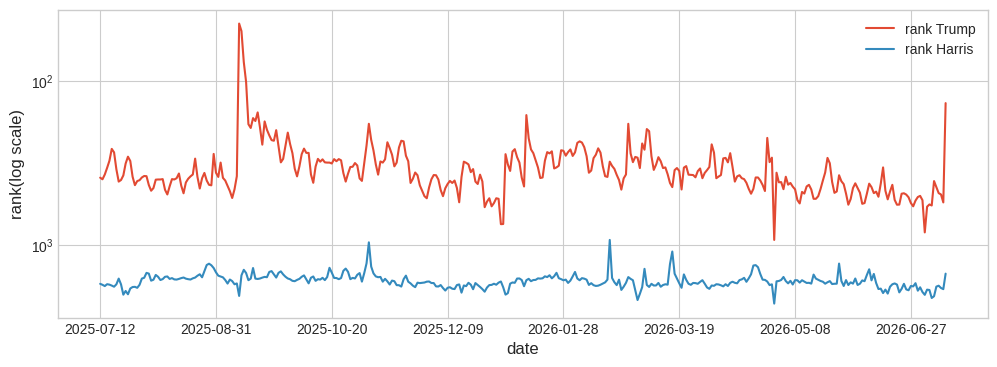

In [ ]:
ax=ts_df.plot(logy=True, figsize=(12,4));
plt.gca().invert_yaxis()
ax.set_ylabel("rank(log scale)");

- easy to customize plot using `pandas` and `matplotlib` combo.

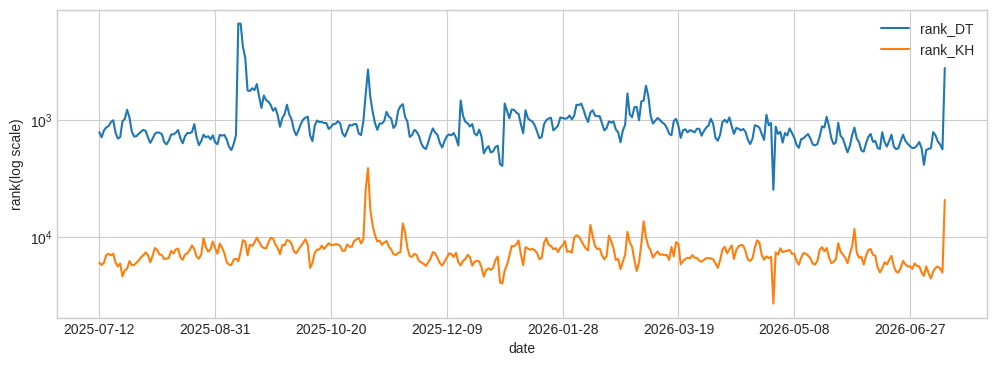

In [ ]:
#bigrams analysis
tsb1 = wiki.term_series("Donald Trump", entity="wikidata:Q30", ngram_size=2, window=365).df().set_index("date").assign(name=lambda x: "Donald Trump")[['rank', 'name']]
tsb2 = wiki.term_series("Kamala Harris", entity="wikidata:Q30", ngram_size=2, window=365).df().set_index("date").assign(name=lambda x: "Kamala Harris")[['rank', 'name']]
tsb_df=pd.merge(tsb1, tsb2, on="date", suffixes=["_DT", "_KH"])

ax=tsb_df.plot(logy=True, figsize=(12,4));
plt.gca().invert_yaxis()
ax.set_ylabel("rank(log scale)");


In [ ]:
#bigrams analysis
tsb_sb_us = wiki.term_series("Super Bowl", entity="United States", ngram_size=2, window=999).df().assign(name=lambda x: "US")[['rank', 'name', 'date']]
tsb_wc_us = wiki.term_series("Fifa World", entity="United States", ngram_size=2, window=999).df().assign(name=lambda x: "US")[['rank', 'name', 'date']]

tsb_sb_uk = wiki.term_series("Super Bowl", entity="United Kingdom", ngram_size=2, window=999).df().assign(name=lambda x: "UK")[['rank', 'name', 'date']]
tsb_wc_uk = wiki.term_series("Fifa World", entity="United Kingdom", ngram_size=2, window=999).df().assign(name=lambda x: "UK")[['rank', 'name', 'date']]

datetime64[ns] 651
datetime64[ns] 651


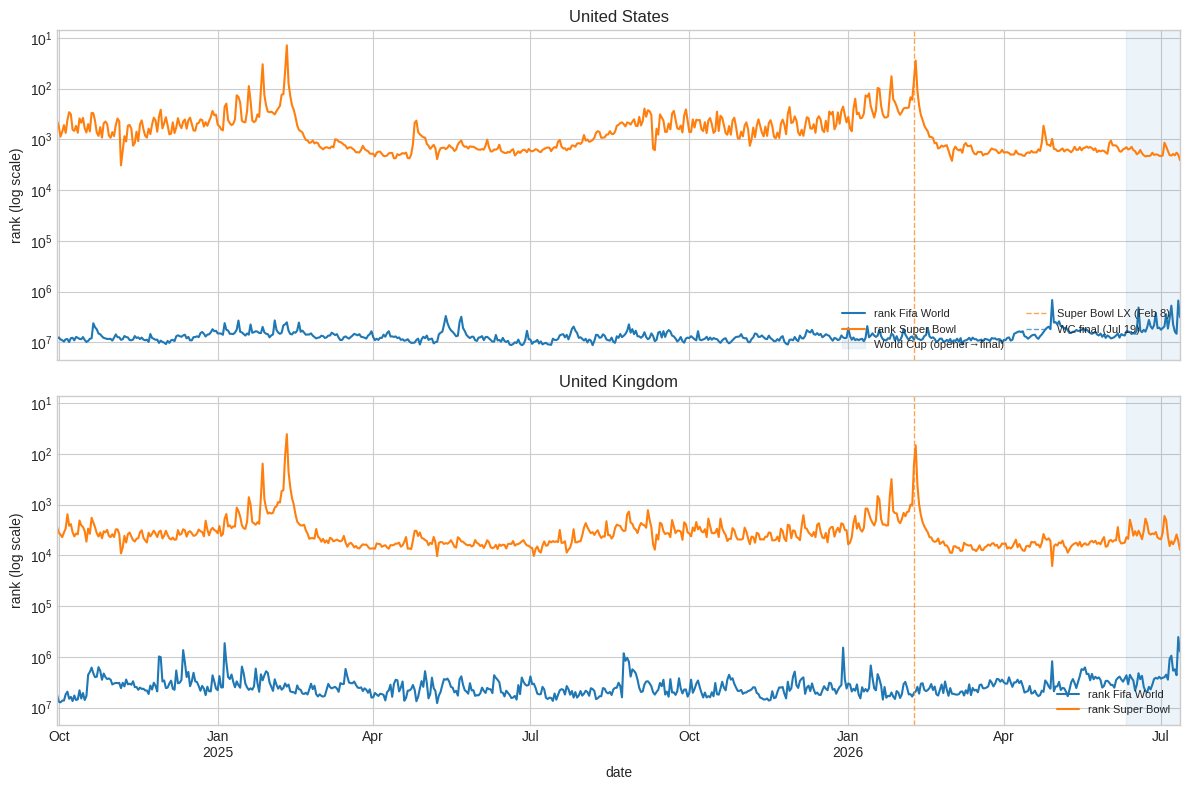

In [ ]:
# --- normalize the join key first (this is what fixes the vline offset) ---
for df in (tsb_wc_us, tsb_sb_us, tsb_wc_uk, tsb_sb_uk):
    df["date"] = pd.to_datetime(df["date"])

# --- data ---
tsb_us_df = (pd.merge(tsb_wc_us, tsb_sb_us, on="date",
                      suffixes=[" Fifa World", " Super Bowl"])
               .set_index("date").sort_index())

tsb_uk_df = (pd.merge(tsb_wc_uk, tsb_sb_uk, on="date",
                      suffixes=[" Fifa World", " Super Bowl"])
               .set_index("date").sort_index())

print(tsb_us_df.index.dtype, len(tsb_us_df))   # expect datetime64[ns]
print(tsb_uk_df.index.dtype, len(tsb_uk_df))

# --- events ---
SB_LX     = pd.Timestamp("2026-02-08")   # Super Bowl LX, Levi's Stadium
WC_OPENER = pd.Timestamp("2026-06-11")   # World Cup opening match
WC_FINAL  = pd.Timestamp("2026-07-19")   # World Cup final, MetLife

# --- plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

tsb_us_df.plot(logy=True, ax=ax1)
tsb_uk_df.plot(logy=True, ax=ax2)

for ax in (ax1, ax2):
    first = ax is ax1  # label once so the legend isn't duplicated
    ax.axvspan(WC_OPENER, WC_FINAL, color="tab:blue", alpha=0.08,
               label="World Cup (opener→final)" if first else None)
    ax.axvline(SB_LX, color="tab:orange", ls="--", lw=1, alpha=0.7,
               label="Super Bowl LX (Feb 8)" if first else None)
    ax.axvline(WC_FINAL, color="tab:blue", ls="--", lw=1, alpha=0.7,
               label="WC final (Jul 19)" if first else None)
    ax.set_ylabel("rank (log scale)")

ax1.set_title("United States")
ax2.set_title("United Kingdom")
ax2.set_xlabel("date")

ax1.invert_yaxis()          # sharey=True → flips both
ax1.legend(loc="lower right", fontsize=8, ncol=2)
ax2.legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()